In [ ]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

list.files(path = "../input")
# Pour le chemin exact :
list.files(path = "/kaggle/input", recursive = TRUE)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

🛸Étude de cas : Observations d'OVNIs en France (GEIPAN)

**1.Introduction & Objectif**
Le but de cette étude est de répertorier et visualiser les observations d'ovnis en France entre 2020 et 2025 pour comprendre à quelle période de l'année elles sont les plus nombreuses.

**Compétences :**
Nettoyage de données complexes ave1. c SQL. Visualisation temporelle avec Tableau. Analyse de saisonnalité.

In [ ]:
library(tidyverse)

# 1. Chargement avec les bons paramètres
path <- "/kaggle/input/datasets/yannmarion/observations-ovnis-geipan/export_cas_pub_20260127144214.csv"

df_ovni <- read_delim(path, 
                      delim = "|", 
                      col_names = FALSE, 
                      show_col_types = FALSE,
                      locale = locale(encoding = "ISO-8859-1"))

# 2. Nettoyage et Stockage dans 'df_final'
df_final <- df_ovni %>%
  select(
    id             = X1,
    ville          = X2,
    date_brute     = X3,
    departement    = X4,
    region         = X5,   # à vérifier si utile
    classification = X13
  ) %>%
  filter(!is.na(date_brute)) %>%
  filter(nchar(as.character(date_brute)) >= 10) %>%
  mutate(
    date_propre = as.Date(date_brute, format = "%d/%m/%Y"),
    annee       = year(date_propre),   # pratique pour Tableau
    mois        = month(date_propre)
  ) %>%
  filter(!is.na(date_propre))  # ← élimine les dates qui n'ont pas parsé

print("Aperçu des données nettoyées :")
view(head(df_final)) # ou juste head(df_final)

# 4. LA COMMANDE POUR GÉNÉRER LE FICHIER CSV
# Ce fichier apparaîtra dans l'onglet 'Output' à droite
write_csv(df_final, "geipan_nettoye_pour_tableau.csv")

print("Fichier CSV généré avec succès !")

Voici les 3 problèmes majeurs que que j'ai résolu dans ce code :

-Les fichiers CSV classiques utilisent la virgule (,). Le fichier du GEIPAN utilise le "pipe" (|). Sans lui préciser delim = "|", R mettait toute la ligne dans une seule colonne géante.

-Le fichier commencçait directement par les données. R essayait de deviner les noms des colonnes en utilisant la première ligne, ce qui créait des noms incohérents comme "1937-01-01656". 


ETAPE DE NETTOYAGE SQL : après avoir organisé le fichier avec du R, j'ai téléchargé le fichier pour le trier et en retiré ce dont j'ai besoin, j'ai utilisé BigQuery pour supprimer les doublons, organiser par date le document, et extraire un échantillon du document qui s'etend de 1937 à 2025.
J'ai extrait les observations entre 2020 et 2025.



```sql
SELECT *
FROM (
  SELECT
    *,
    ROW_NUMBER() OVER (
      PARTITION BY id
      ORDER BY date_propre
    ) AS rn
  FROM `observations-ovnis-490210.Ovnis_Geipan.table_clean`
  WHERE date_propre IS NOT NULL
  AND EXTRACT(YEAR FROM date_propre) BETWEEN 2020 AND 2025  
)
WHERE rn = 1
ORDER BY date_propre ASC;

j'ai ensuite nettoyé le fichier et rajouté des regions et fais differentes optimisation pour faire une visualisation dans tableau avec l'aide de cette requête SQL :
**Objectifs de la requête :**
* **Mapping Géographique :** Regroupement des départements en régions françaises.
* **Extraction Temporelle :** Extraction de l'année à partir de la date nettoyée.
* **Agrégation :** Calcul du nombre d'observations uniques par secteur et par an.

```sql
SELECT 
    'France' AS pays, 
    region, 
    departement, 
    EXTRACT(YEAR FROM date_propre) AS annee, 
    COUNT(DISTINCT id) AS nb_observations 
FROM ( 
    SELECT 
        id, 
        date_propre, 
        departement, 
        CASE 
            WHEN departement IN ('75','77','78','91','92','93','94','95') THEN 'Île-de-France' 
            WHEN departement IN ('02','59','60','62','80') THEN 'Hauts-de-France' 
            WHEN departement IN ('08','10','51','52','54','55','57','67','68','88') THEN 'Grand Est' 
            WHEN departement IN ('21','25','39','58','70','71','89','90') THEN 'Bourgogne-Franche-Comté' 
            WHEN departement IN ('01','03','07','15','26','38','42','43','63','69','73','74') THEN 'Auvergne-Rhône-Alpes' 
            WHEN departement IN ('04','05','06','13','83','84') THEN 'Provence-Alpes-Côte d Azur' 
            WHEN departement IN ('09','11','12','30','31','32','34','46','48','65','66','81','82') THEN 'Occitanie' 
            WHEN departement IN ('16','17','19','23','24','33','40','47','64','79','86','87') THEN 'Nouvelle-Aquitaine' 
            WHEN departement IN ('18','28','36','37','41','45') THEN 'Centre-Val de Loire' 
            WHEN departement IN ('22','29','35','56') THEN 'Bretagne' 
            WHEN departement IN ('44','49','53','72','85') THEN 'Pays de la Loire' 
            WHEN departement IN ('14','27','50','61','76') THEN 'Normandie' 
            WHEN departement IN ('971','972','973','974') THEN 'Outre-Mer'
            ELSE 'Autre' 
        END AS region 
    FROM `observations-ovnis-490210.Ovnis_Geipan.table_clean` 
    WHERE date_propre IS NOT NULL 
) 
WHERE region != 'Autre' 
GROUP BY pays, region, departement, annee 
ORDER BY annee, nb_observations DESC;
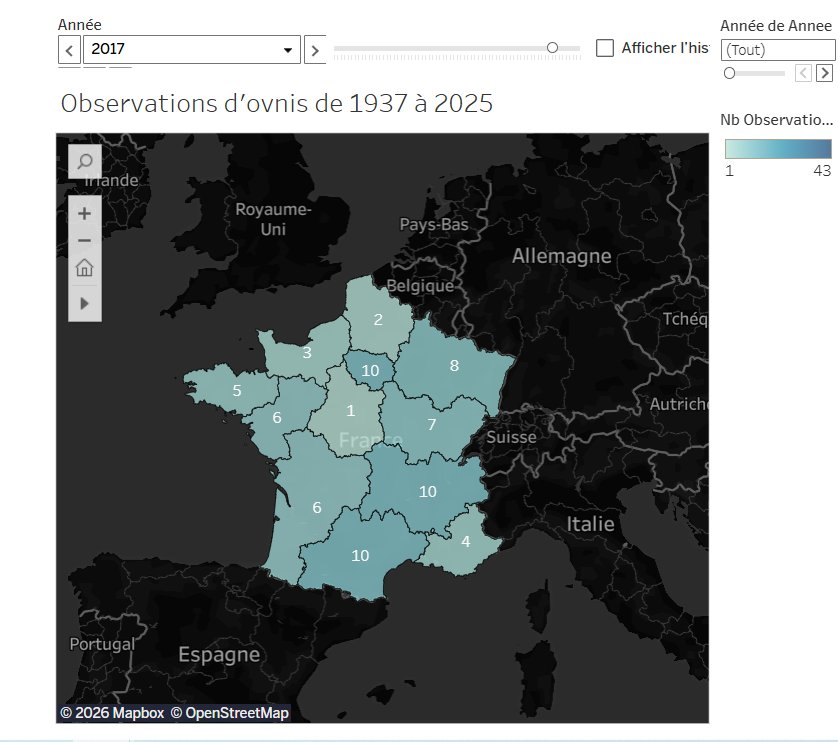

j'ai ensuite creer un visuel a partir du fichier

In [ ]:
# Utilisation de la bibliothèque htmltools pour l'intégration
library(htmltools)


tableau_url <- "https://public.tableau.com/views/Observations_ovnis/Tableaudebord1?:embed=y&:showVizHome=n&:mobile=y"


browsable(
  tags$iframe(
    src = tableau_url,
    width = "100%",
    height = "700px",  
    style = "border:none;"
  )
)

### 💡 Conclusions de l'analyse

Grâce au nettoyage et à la segmentation par régions, plusieurs tendances se dessinent :
* **Répartition géographique :** On observe une concentration plus forte dans certaines régions, ce qui peut être lié à la clarté du ciel ou à la présence de bases aéronautiques.
* **Évolution temporelle :** Vérifier si les pics d'observations coïncident souvent avec des périodes de médiatisation forte ou de lancements spatiaux.
* **Points intéressants :** Les régions sud de la france ont le plus d'observations repertorié par le GEIPAN, à verifier si cela a un lien avec des évenements spaciaux ou des projets militaires ou autres.

